## Random Forest

- ML algorithm that uses many decision trees to make better predictions
- Each tree looks at different random part of the data and their results are combined by voting for classification or averaging for regression which makes it on essemble learning technique
- Helps in improving accuracy and reducing errors
- Create many decision trees
- pick random features
- each tree makes a prediction
- combine the predictions

1. Bagging(Bootstrap aggregating)
- it takes your data set and creates random samples with replacement
- if you have 100 data
- Tree1 -->1,5,20,50
- Tree2 -->2,9,15,80

In [9]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
x=df[["Parch","Sex","Age","SibSp","Pclass","Fare"]]
y=df["Survived"]

In [12]:
import warnings
warnings.filterwarnings("ignore")
x['Sex']=x["Sex"].map({"female":0,"male":1})
x["Age"]=x["Age"].fillna(x["Age"].mean())

In [13]:
x

,Parch,Sex,Age,SibSp,Pclass,Fare
0,0,1,22.000000,1,3,7.2500
1,0,0,38.000000,1,1,71.2833
2,0,0,26.000000,0,3,7.9250
3,0,0,35.000000,1,1,53.1000
4,0,1,35.000000,0,3,8.0500
...,...,...,...,...,...,...
886,0,1,27.000000,0,2,13.0000
887,0,0,19.000000,0,1,30.0000
888,2,0,29.699118,1,3,23.4500
889,0,1,26.000000,0,1,30.0000


In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(712, 6)
(712,)
(179, 6)
(179,)


In [37]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=42)
rf_classifier.fit(x_train,y_train)
ypred=rf_classifier.predict(x_test)
print(ypred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [38]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,ypred))

Accuracy: 0.776536312849162


In [39]:
sample=x_test.iloc[0:1]
print(sample)
prediction=rf_classifier.predict(sample)
prediction

     Parch  Sex   Age  SibSp  Pclass     Fare
862      0    0  48.0      0       1  25.9292


array([1])

In [40]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"sample Passenger data: {sample_dict}")
print(f"predicted survival:{'survived' if prediction[0]==1 else'Not survived'}")

{'Parch': 0.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Pclass': 1.0, 'Fare': 25.9292}
sample Passenger data: {'Parch': 0.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Pclass': 1.0, 'Fare': 25.9292}
predicted survival:survived


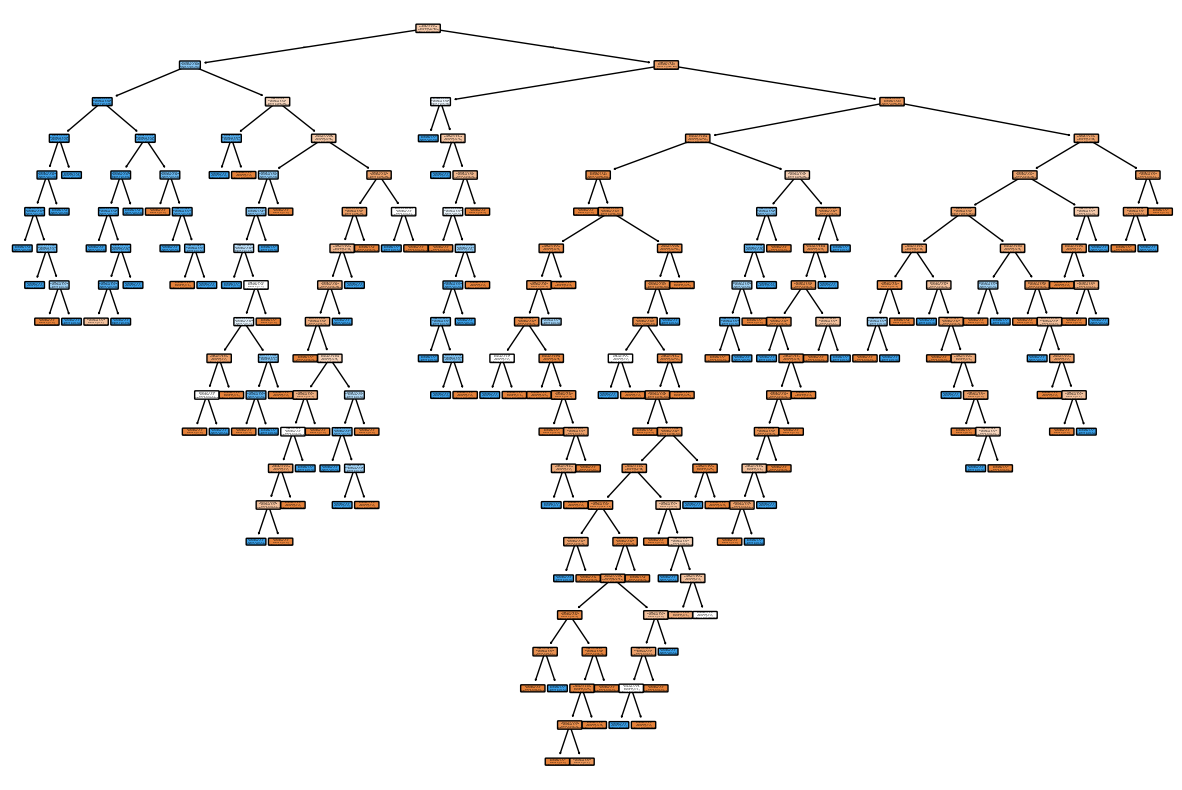

In [41]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf_classifier.estimators_[0]
plt.figure(figsize=(15,10))
plot_tree(chosen_tree,feature_names=x.columns,class_names=["Not Survived","Survived"],filled=True,rounded=True)
plt.show()

In [43]:
import pandas as pd
import numpy as np
df=pd.DataFrame({"Weight":[150,170,140,180,160,155],"Texture":["smooth","Rough","smooth","Rough","smooth","Rough"],"Color":["Red","Orange","Green","Orange","Red","Yellow"],
                "Fruit":["Apple","orange","Apple","orange","Apple","orange"]})
df

,Weight,Texture,Color,Fruit
0,150,smooth,Red,Apple
1,170,Rough,Orange,orange
2,140,smooth,Green,Apple
3,180,Rough,Orange,orange
4,160,smooth,Red,Apple
5,155,Rough,Yellow,orange


In [44]:
df["Texture"]=np.where(df["Texture"]=="smooth",0,1)
df["Color"]=np.where(df["Color"]=="Red",0,np.where(df["Color"]=="Orange",1,np.where(df["Color"]=="Green",2,3)))
df

,Weight,Texture,Color,Fruit
0,150,0,0,Apple
1,170,1,1,orange
2,140,0,2,Apple
3,180,1,1,orange
4,160,0,0,Apple
5,155,1,3,orange


In [57]:
x=df.iloc[:,0:3]
y=df["Fruit"]
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [58]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=42)
rf_classifier.fit(x,y)
ypred=rf_classifier.predict(x)
print(ypred)

['Apple' 'orange' 'Apple' 'orange' 'Apple' 'orange']


In [59]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y,ypred))

Accuracy: 1.0


In [60]:
sample=x.iloc[0:1]
print(sample)
prediction=rf_classifier.predict(sample)
prediction

   Weight  Texture  Color
0     150        0      0


array(['Apple'], dtype=object)

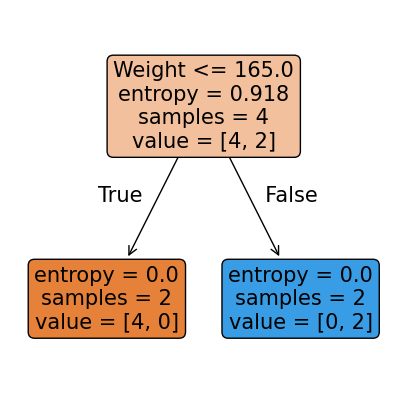

In [61]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf_classifier.estimators_[0]
plt.figure(figsize=(5,5))
plot_tree(chosen_tree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

## Support Vector Machine
- SVM is complex classification tasks
- SVM looks for the optimal hyperplane that best separates different classes in a dataset
#### Decision boundary - line that separates the classes
#### Margin - Distance between the line and the nearest points of each class
#### Support vectors - data points that sit right at the edge of the decision boundary. These are most important points beacsuse if you move them  boundary moves

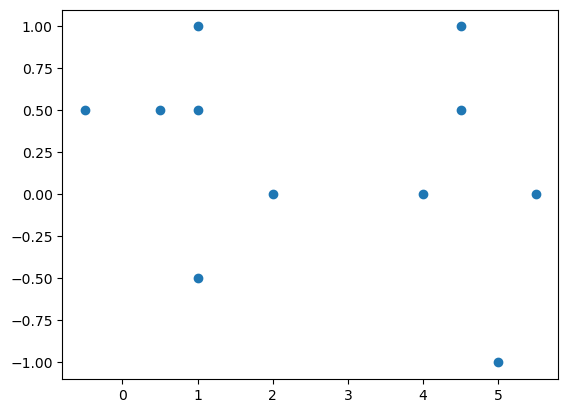

In [62]:
x=[1,1,1,-0.5,0.5,2,4,4.5,4.5,5,5.5]
y=[0.5,1,-0.5,0.5,0.5,0,0,1,0.5,-1,0]
plt.scatter(x,y)

In [64]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [71]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [74]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf",C=1.0,random_state=1)
classifier.fit(x_train,y_train)
prediction=classifier.predict(x_test)
print(prediction)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


- rbf =>radial basis function
- C =>Regularization
- Controls the trade off between maximizing the margin and minimizing the misclassification
- high C=>prioritizes correct classification (smaller margin)
- low C => allows more misclassification to achieve a wider smooth margin error penalty low